[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/harshuljain13/llm-inference-at-scale/blob/master/content/02_sizing_and_serving/02.1_vram_budget/lab.ipynb) [![Open In Molab](https://img.shields.io/badge/Open%20in-Molab-blue)](https://molab.marimo.io/github/harshuljain13/llm-inference-at-scale/blob/master/content/02_sizing_and_serving/02.1_vram_budget/lab.ipynb)

# Lab 2.1: Capacity Planning Calculator

Interactive capacity planner. Pick your model, GPU, and precision to see how many users you can serve.

In [1]:
# Install dependencies (quiet mode)
%pip install -q ipywidgets matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


## Setup: Model and GPU Database

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --- Model specifications ---
# params: billions of parameters
# n_layers: transformer layers
# n_kv_heads: number of KV attention heads (for GQA models, fewer than query heads)
# head_dim: dimension per attention head
MODELS = {
    "Llama-8B":    {"params": 8,   "n_layers": 32,  "n_kv_heads": 8,   "head_dim": 128},
    "Llama-70B":   {"params": 70,  "n_layers": 80,  "n_kv_heads": 8,   "head_dim": 128},
    "Llama-405B":  {"params": 405, "n_layers": 126, "n_kv_heads": 8,   "head_dim": 128},
    "Mistral-7B":  {"params": 7,   "n_layers": 32,  "n_kv_heads": 8,   "head_dim": 128},
    "Mixtral-8x7B":{"params": 47,  "n_layers": 32,  "n_kv_heads": 8,   "head_dim": 128},
}

# --- GPU specifications ---
# vram_gb: total GPU memory in GB
# bandwidth_gbs: memory bandwidth in GB/s
# cost_per_hr: approximate cloud cost in $/hr
GPUS = {
    "T4":   {"vram_gb": 16,  "bandwidth_gbs": 320,  "cost_per_hr": 0.50},
    "A10G": {"vram_gb": 24,  "bandwidth_gbs": 600,  "cost_per_hr": 1.00},
    "A100": {"vram_gb": 80,  "bandwidth_gbs": 2039, "cost_per_hr": 3.50},
    "H100": {"vram_gb": 80,  "bandwidth_gbs": 3350, "cost_per_hr": 5.00},
    "H200": {"vram_gb": 141, "bandwidth_gbs": 4800, "cost_per_hr": 7.50},
}

# --- Precision: bytes per parameter/element ---
PRECISIONS = {
    "FP16": 2,    # 16-bit floating point
    "INT8": 1,    # 8-bit integer quantization
    "INT4": 0.5,  # 4-bit quantization (2 params per byte)
    "FP8":  1,    # 8-bit floating point (Hopper+)
}

print("Loaded: {} models, {} GPUs, {} precisions".format(len(MODELS), len(GPUS), len(PRECISIONS)))

Loaded: 5 models, 5 GPUs, 4 precisions


## The Calculator

In [3]:
def capacity_plan(model_name, gpu_name, precision_name, context_len=4096, target_batch=32):
    """Compute VRAM budget and capacity for a given configuration."""
    model = MODELS[model_name]
    gpu = GPUS[gpu_name]
    bytes_per_param = PRECISIONS[precision_name]

    # Weight memory: params (billions) * bytes_per_param -> GB
    weight_gb = model["params"] * bytes_per_param

    # KV cache per token per layer: 2 (K+V) * n_kv_heads * head_dim * bytes_per_element
    # We use FP16 (2 bytes) for KV regardless of weight precision
    kv_bytes_per_token_per_layer = 2 * model["n_kv_heads"] * model["head_dim"] * 2
    # Total KV per token across all layers (in KB)
    kv_per_token_kb = (kv_bytes_per_token_per_layer * model["n_layers"]) / 1024

    # KV cache for the full batch at full context length (in GB)
    kv_total_gb = (kv_per_token_kb * 1024 * context_len * target_batch) / (1024**3)

    # Runtime overhead: activations, CUDA kernels (~10% of weights or 1GB min)
    overhead_gb = max(1.0, weight_gb * 0.10)

    # Total memory required
    total_gb = weight_gb + kv_total_gb + overhead_gb
    fits = total_gb <= gpu["vram_gb"]

    # Max batch size that fits (binary search)
    max_batch = 0
    for b in range(1, 1024):
        kv_b = (kv_per_token_kb * 1024 * context_len * b) / (1024**3)
        if weight_gb + kv_b + overhead_gb > gpu["vram_gb"]:
            break
        max_batch = b

    headroom_gb = gpu["vram_gb"] - total_gb

    result = {
        "weight_gb": round(weight_gb, 2),
        "kv_per_token_kb": round(kv_per_token_kb, 2),
        "kv_total_gb": round(kv_total_gb, 2),
        "overhead_gb": round(overhead_gb, 2),
        "total_gb": round(total_gb, 2),
        "fits": fits,
        "max_batch": max_batch,
        "headroom_gb": round(headroom_gb, 2),
    }

    # Print formatted report
    status = "\033[92mFITS\033[0m" if fits else "\033[91mOOM\033[0m"
    print(f"=== {model_name} on {gpu_name} ({precision_name}, ctx={context_len}) ===")
    print(f"  Weights:    {result['weight_gb']:.1f} GB")
    print(f"  KV Cache:   {result['kv_total_gb']:.1f} GB (batch={target_batch})")
    print(f"  Overhead:   {result['overhead_gb']:.1f} GB")
    print(f"  Total:      {result['total_gb']:.1f} / {gpu['vram_gb']} GB  [{status}]")
    print(f"  Max batch:  {result['max_batch']} concurrent sequences")
    print(f"  Headroom:   {result['headroom_gb']:.1f} GB")
    return result

# Example usage
capacity_plan("Llama-8B", "A100", "FP16", context_len=4096, target_batch=32)

=== Llama-8B on A100 (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   16.0 GB (batch=32)
  Overhead:   1.6 GB
  Total:      33.6 / 80 GB  [FITS]
  Max batch:  124 concurrent sequences
  Headroom:   46.4 GB


{'weight_gb': 16,
 'kv_per_token_kb': 128.0,
 'kv_total_gb': 16.0,
 'overhead_gb': 1.6,
 'total_gb': 33.6,
 'fits': True,
 'max_batch': 124,
 'headroom_gb': 46.4}

## Interactive Explorer

In [ ]:
# NOTE: "batch size" = number of concurrent users (active conversations at the same time).
# Each user in the batch holds their own KV cache in GPU memory.
def interactive_planner(model, gpu, precision, context_length, batch_size):
    """Interactive widget callback: compute and visualize capacity."""
    result = capacity_plan(model, gpu, precision, context_length, batch_size)

    # Stacked bar chart: memory breakdown vs GPU capacity
    fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    categories = ["Used"]
    weights = [result["weight_gb"]]
    kv = [result["kv_total_gb"]]
    overhead = [result["overhead_gb"]]

    # Pastel colors for stacked bars
    ax.barh(categories, weights, color="#dbeafe", edgecolor="#000", label="Weights")
    ax.barh(categories, kv, left=weights, color="#dcfce7", edgecolor="#000", label="KV Cache")
    ax.barh(categories, overhead, left=[w+k for w,k in zip(weights, kv)],
            color="#fef3c7", edgecolor="#000", label="Overhead")

    # GPU VRAM capacity line
    vram = GPUS[gpu]["vram_gb"]
    ax.axvline(x=vram, color="#991b1b", linestyle="--", linewidth=2, label=f"GPU VRAM ({vram} GB)")

    ax.set_xlabel("Memory (GB)")
    ax.set_title("VRAM Budget Breakdown", fontsize=12)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim(0, max(vram * 1.2, result["total_gb"] * 1.1))
    plt.tight_layout()
    plt.show()

# Build interactive widget
widgets.interactive(
    interactive_planner,
    model=widgets.Dropdown(options=list(MODELS.keys()), value="Llama-8B", description="Model:"),
    gpu=widgets.Dropdown(options=list(GPUS.keys()), value="A100", description="GPU:"),
    precision=widgets.Dropdown(options=list(PRECISIONS.keys()), value="FP16", description="Precision:"),
    context_length=widgets.IntSlider(min=512, max=32768, step=512, value=4096, description="Context:"),
    batch_size=widgets.IntSlider(min=1, max=256, step=1, value=32, description="Batch:"),
)

interactive(children=(Dropdown(description='Model:', options=('Llama-8B', 'Llama-70B', 'Llama-405B', 'Mistral-…

## Comparison Chart: All GPUs

=== Llama-8B on T4 (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   0.5 GB (batch=1)
  Overhead:   1.6 GB
  Total:      18.1 / 16 GB  [OOM]
  Max batch:  0 concurrent sequences
  Headroom:   -2.1 GB
=== Llama-8B on A10G (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   0.5 GB (batch=1)
  Overhead:   1.6 GB
  Total:      18.1 / 24 GB  [FITS]
  Max batch:  12 concurrent sequences
  Headroom:   5.9 GB
=== Llama-8B on A100 (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   0.5 GB (batch=1)
  Overhead:   1.6 GB
  Total:      18.1 / 80 GB  [FITS]
  Max batch:  124 concurrent sequences
  Headroom:   61.9 GB
=== Llama-8B on H100 (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   0.5 GB (batch=1)
  Overhead:   1.6 GB
  Total:      18.1 / 80 GB  [FITS]
  Max batch:  124 concurrent sequences
  Headroom:   61.9 GB
=== Llama-8B on H200 (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   0.5 GB (batch=1)
  Overhead:   1.6 GB
  Total:      18.1 / 141 GB  [FITS]
  Max b

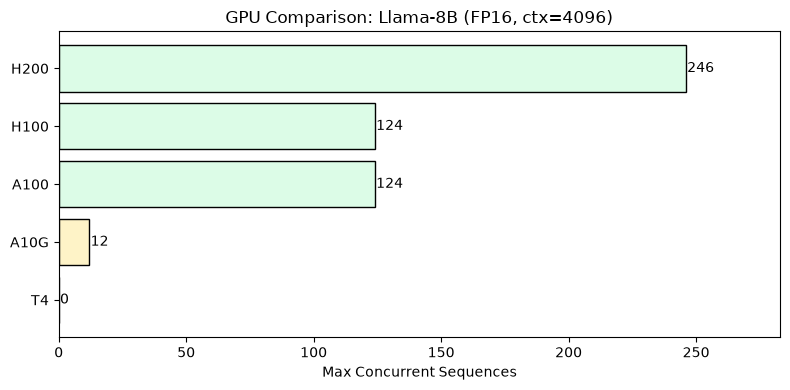

In [5]:
def compare_gpus(model_name="Llama-8B", precision_name="FP16", context_len=4096):
    """Compare max concurrent users across all GPUs for a given model config."""
    gpu_names = list(GPUS.keys())
    max_batches = []
    costs = []

    # Compute max batch for each GPU
    for gname in gpu_names:
        result = capacity_plan(model_name, gname, precision_name, context_len, 1)
        max_batches.append(result["max_batch"])
        costs.append(GPUS[gname]["cost_per_hr"])

    # Color by cost efficiency (max_batch / cost)
    efficiencies = [mb / c if c > 0 else 0 for mb, c in zip(max_batches, costs)]
    max_eff = max(efficiencies) if max(efficiencies) > 0 else 1
    # Pastel green for efficient, pastel rose for expensive
    colors = [
        "#dcfce7" if e > 0.6 * max_eff else "#fef3c7" if e > 0.3 * max_eff else "#ffe4e6"
        for e in efficiencies
    ]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(gpu_names, max_batches, color=colors, edgecolor="#000")

    # Annotate bars with batch count
    for bar, mb in zip(bars, max_batches):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(mb), va="center", fontsize=10)

    ax.set_xlabel("Max Concurrent Sequences")
    ax.set_title(f"GPU Comparison: {model_name} ({precision_name}, ctx={context_len})", fontsize=12)
    ax.set_xlim(0, max(max_batches) * 1.15 if max(max_batches) > 0 else 10)
    plt.tight_layout()
    plt.show()

# Run comparison for default model
compare_gpus("Llama-8B", "FP16", 4096)

## Cost Analysis

=== Llama-8B on T4 (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   16.0 GB (batch=32)
  Overhead:   1.6 GB
  Total:      33.6 / 16 GB  [OOM]
  Max batch:  0 concurrent sequences
  Headroom:   -17.6 GB
=== Llama-8B on A10G (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   16.0 GB (batch=32)
  Overhead:   1.6 GB
  Total:      33.6 / 24 GB  [OOM]
  Max batch:  12 concurrent sequences
  Headroom:   -9.6 GB
=== Llama-8B on A100 (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   16.0 GB (batch=32)
  Overhead:   1.6 GB
  Total:      33.6 / 80 GB  [FITS]
  Max batch:  124 concurrent sequences
  Headroom:   46.4 GB
=== Llama-8B on H100 (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   16.0 GB (batch=32)
  Overhead:   1.6 GB
  Total:      33.6 / 80 GB  [FITS]
  Max batch:  124 concurrent sequences
  Headroom:   46.4 GB
=== Llama-8B on H200 (FP16, ctx=4096) ===
  Weights:    16.0 GB
  KV Cache:   16.0 GB (batch=32)
  Overhead:   1.6 GB
  Total:      33.6 / 141 GB  [FI

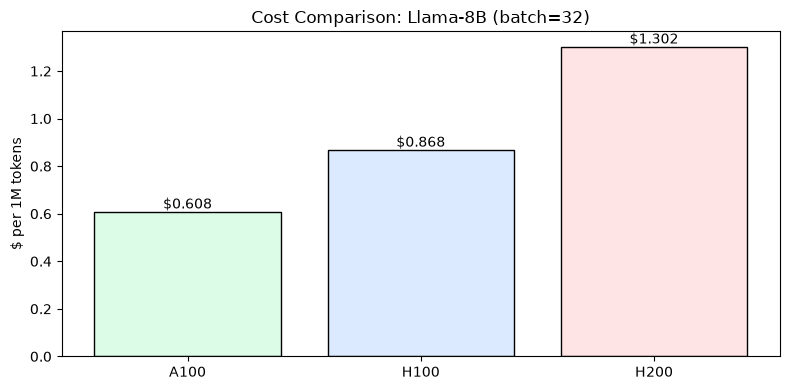


Recommendation: A100 at $0.608/1M tokens
  (cheapest GPU that serves batch=32 for Llama-8B)


In [6]:
def cost_analysis(model_name="Llama-8B", precision_name="FP16",
                   context_len=4096, target_batch=32, tokens_per_request=512):
    """Compute and compare cost per 1M tokens across GPUs."""
    gpu_names = list(GPUS.keys())
    costs_per_1m = []
    viable = []

    for gname in gpu_names:
        gpu = GPUS[gname]
        result = capacity_plan(model_name, gname, precision_name, context_len, target_batch)

        if result["max_batch"] >= target_batch:
            # Tokens per hour = batch_size * tokens_per_request * (3600 / time_per_request)
            # Simplified: assume decode-bound at ~50 tokens/sec per sequence
            tokens_per_sec = 50 * target_batch
            tokens_per_hr = tokens_per_sec * 3600
            cost_1m = (gpu["cost_per_hr"] / tokens_per_hr) * 1_000_000
            costs_per_1m.append(round(cost_1m, 3))
            viable.append(True)
        else:
            # Cannot serve target batch -- mark as N/A
            costs_per_1m.append(None)
            viable.append(False)

    # Plot viable options
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_names = []
    plot_costs = []
    plot_colors = []

    for name, cost, v in zip(gpu_names, costs_per_1m, viable):
        if v and cost is not None:
            plot_names.append(name)
            plot_costs.append(cost)

    # Sort by cost
    sorted_pairs = sorted(zip(plot_costs, plot_names))
    plot_costs = [p[0] for p in sorted_pairs]
    plot_names = [p[1] for p in sorted_pairs]
    # Cheapest = green, most expensive = rose
    plot_colors = ["#dcfce7"] + ["#dbeafe"] * (len(plot_names) - 2) + ["#ffe4e6"] if len(plot_names) > 2 else ["#dcfce7"] * len(plot_names)

    bars = ax.bar(plot_names, plot_costs, color=plot_colors, edgecolor="#000")
    ax.set_ylabel("$ per 1M tokens")
    ax.set_title(f"Cost Comparison: {model_name} (batch={target_batch})", fontsize=12)

    # Annotate
    for bar, cost in zip(bars, plot_costs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f"${cost:.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()

    # Print recommendation
    if plot_names:
        print(f"\n\033[92mRecommendation:\033[0m {plot_names[0]} at ${plot_costs[0]:.3f}/1M tokens")
        print(f"  (cheapest GPU that serves batch={target_batch} for {model_name})")
    else:
        print("\033[91mNo single GPU can serve this configuration. Consider tensor parallelism.\033[0m")

cost_analysis("Llama-8B", "FP16", 4096, target_batch=32)

## Key Takeaways

1. **Weights dominate small-batch VRAM** but KV cache dominates at high batch sizes and long contexts
2. **Quantization is the cheapest scaling lever**: INT4 cuts weight memory 4x, enabling larger batches on smaller GPUs
3. **Cost efficiency != raw capacity**: A100 often beats H100 on $/token for models that fit in 80GB
4. **Context length is the hidden killer**: doubling context halves your max batch size (KV scales linearly with sequence length)
5. **Always budget 10% overhead**: CUDA kernels, activations, and framework allocations add up